# Métropole du Grand Nancy

# 0. Configuration

In [3]:
# !pip install osmnx
# !pip install scikit-image

In [36]:
import os
import sys
import numpy as np
import geopandas as gpd
import ee
import matplotlib.pyplot as plt

# personal modules
sys.path.insert(1, '../../marion/corridor_project/modules/')
import landcover as lc
import connectivity as conn
import routing as rout
sys.path.insert(1, '../../marion/corridor_project/config/')
import species_params

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Nancy"
GUILD_KEY = "mid_walker"
specie = species_params.SPECIES_CONFIG[GUILD_KEY]
OUTPUT_DIR = f"/home/jovyan/work/team/marion/corridor_project/results_connectivity/{CITY}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
url_aoi = "https://geo.api.gouv.fr/epcis?nom=Grand%20Nancy&format=geojson&geometry=contour"
aoi_raw = gpd.read_file(url_aoi)
dept = "D054"

Skipping field codesDepartements: unsupported OGR type: 5
Skipping field codesRegions: unsupported OGR type: 5


In [41]:
import importlib
from modules import landcover as lc
from modules import connectivity as conn
from modules import routing as rout
import species_params
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(species_params)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/config/species_params.py'>

# 1. Landcover

Landcover raster combining ESA WorldCover and OSM Highways

In [42]:
aoi_utm, aoi_ee, utm_epsg = lc.setup_aoi(aoi_raw)
da_lc = lc.get_city_landcover(aoi_ee, aoi_utm, aoi_raw, utm_epsg, specie['habitat_codes'])
print(f"Valeurs : {np.unique(da_lc.values)}")

# da_export = da_lc.fillna(0).astype('uint8')
# da_export.rio.to_raster(f"{OUTPUT_DIR}/landcover_{CITY}.tif")

/opt/conda/lib/python3.11/site-packages/xee/ext.py:685: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Valeurs : [10. 30. 40. 50. 51. 52. 53. 54. 60. 80. 90. nan]


# 2. Habitat Morphology - MSPA

Identifies morphological connectivity elements (nodes and stepping stones) based on species preferences

In [43]:
binary_wc = conn.get_binary_habitat(da_lc, specie['habitat_codes'])

gdf_cores, gdf_islets = conn.get_connectivity_elements(binary_wc, core_min_ha=1.0, islet_min_ha=0.1)
print(f"✓ {len(gdf_cores)} Noyaux de biodiversité et {len(gdf_islets)} Stepping Stones (Islets + Petits Cores) identifiés.")
if len(gdf_islets) > 0:
    print(gdf_islets['class'].value_counts())
    
# binary_wc.rio.to_raster(f"{OUTPUT_DIR}/binary_habitat_{CITY}.tif")
# gdf_cores.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_islets.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_cores.to_file(f"{OUTPUT_DIR}/cores_{CITY}.json", driver='GeoJSON')
# gdf_islets.to_file(f"{OUTPUT_DIR}/islets_{CITY}.json", driver='GeoJSON')

✓ 162 Noyaux de biodiversité et 1571 Stepping Stones (Islets + Petits Cores) identifiés.
class
Stepping Stone (Small Core)    975
Stepping Stone (Islet)         596
Name: count, dtype: int64


# 3. Graph Connectivity Analysis

## 3.1. Network modeling

The landscape is modeled as a graph where Nodes represent habitat patches and Edges represent potential dispersal links.
- Probabilistic approach: Connection strength is based on an exponential decay function relative to the species dispersal distance ($d_0$) - probability of movement between patches.
  > what i tried: K-nearest neighbors graph (feels forced, too little or too far, no distance involved), Relative neighborhood graph (too restrictive, no loops), Gabriel graph (capture local neighborhood, redundancy allowed)

  
- Gabriel graph is the approach adopted, seems to be the better trade-off
     - **Step 1**: To be quicker, it doesn't check every habitat against every other one but it looks at a patch and search for other patches at ($2 \times d0$) of it. It calculates the Edge-to-Edge distance (instead of centroid-to-centroid).
     - **Step 2**: The Gabriel Filter (= shortcuts rule), it draws an imaginary circle where the path between A and B is the diameter. If there is another Habitat C inside that circle, the path between A and B is deleted.
     - **Step 3**: If a path survives the filter, it calculates how likely it is to actually make the trip:
        1. Probability ($prob$): It uses an exponential decay, the further the distance, the lower the chance of movement.
        2. Cost: It converts that probability into a "cost" (logarithm), to find the shortest/safest path. 

In [44]:
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)
# G_knn = conn.build_connectivity_graph_knn(df_nodes, specie)
# G_rng = conn.build_rng_graph(df_nodes, specie)
G = conn.build_gabriel_graph(df_nodes, specie)

Étape 2/2: Filtrage Gabriel: 100%|██████████| 553403/553403 [01:38<00:00, 5609.17it/s]

Graphe de Gabriel construit : 1733 nœuds et 3731 arêtes.


## 3.2. Theoretical PC index

Probability of Connectivity (PC) Index measures landscape permeability for a given functional guild. It represents the probability that 2 points randomly placed in the city fall within connected habitat patches.
> Remark: Now that we use edge-to-edge instead of centroids, the internal distance is not taken into account, this can overestimates connectivity beacuse it ignores the space occupied by the patch itself  
> Assumption: movement inside patches is free  

In [47]:
total_area_km2 = aoi_utm.area.sum() / 1e6
pc_value = conn.calculate_pc_index(G, total_area_km2)
print(f"Indice PC pour {CITY} : {pc_value:.4f}")

gdf_edges = conn.graph_to_gdf_edges(G, utm_epsg)
# gdf_edges.to_file(f"{OUTPUT_DIR}/edges_{CITY}.json", driver='GeoJSON')

Indice PC pour Nancy : 0.2332


# 4. Least Cost Path Analysis

From euclidean distance to real-world distance that accounts for landscape friction. Simulation of the optimal path for a given species between each node.

In [48]:
gdf_lcp = rout.compute_lcp_network(gdf_edges, df_nodes, da_lc, specie['friction'])

gdf_lcp['tortuosity'] = gdf_lcp['real_dist'] / gdf_lcp['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp['tortuosity'].mean():.3f}")
print(f"Median Tortuosity for {CITY}: {gdf_lcp['tortuosity'].median():.3f}")
# print(gdf_lcp['tortuosity'].describe())

Tracing LCPs: 100%|██████████| 3731/3731 [04:04<00:00, 15.27it/s] 

Success: 3731 corridors traced (0 failed).
Average Tortuosity for Nancy: 3.342
Median Tortuosity for Nancy: 1.712


## 4.1. Network metrics: PC

By comparing the Theoretical PC (Euclidean from Graph) with the Real PC (LCP), we quantify the connectivity loss. This delta quantifies the impact of human infrastructure and urban matrix on species mobility.

In [57]:
pc_real, G_lcp = conn.calculate_pc_index_lcp(G=G, total_area_km2=total_area_km2, species_params=specie, gdf_lcp=gdf_lcp)
print(f"Theoretical PC (euclidian) : {pc_value:.6f}")
print(f"Real PC (LCP) : {pc_real:.6f}")
print(f"Fragmentation impact : {((pc_value - pc_real) / pc_value)*100:.1f}% connectivity loss.")

Theoretical PC (euclidian) : 0.233197
Real PC (LCP) : 0.170841
Fragmentation impact : 26.7% connectivity loss.


In [82]:
# Option A : Biologique (Si d0 est connu et fiable)
d0 = specie['graph']['d0']
biological_threshold = 3 * d0

# Option B : Statistique (Robuste si le d0 est incertain)
IQR = 447 - 133
statistical_threshold = 447 + 1.5 * IQR

# Choisissez le plus grand des deux pour être prudent
threshold = max(biological_threshold, statistical_threshold)

print(f"Seuil de filtre appliqué : {threshold:.0f}")

# Application
gdf_lcp_clean = gdf_lcp[gdf_lcp['accumulated_cost'] <= threshold].copy()

print(f"Nombre de corridors avant : {len(gdf_lcp)}")
print(f"Nombre de corridors après : {len(gdf_lcp_clean)}")
print(f"Nombre de chemins 'absurdes' supprimés : {len(gdf_lcp) - len(gdf_lcp_clean)}")

Seuil de filtre appliqué : 6000
Nombre de corridors avant : 3731
Nombre de corridors après : 3645
Nombre de chemins 'absurdes' supprimés : 86


In [86]:
pc_real, G_lcp = conn.calculate_pc_index_lcp(G, total_area_km2, specie, gdf_lcp_clean)
print(f"Real PC (LCP) : {pc_real:.6f}")

Real PC (LCP) : 0.172439


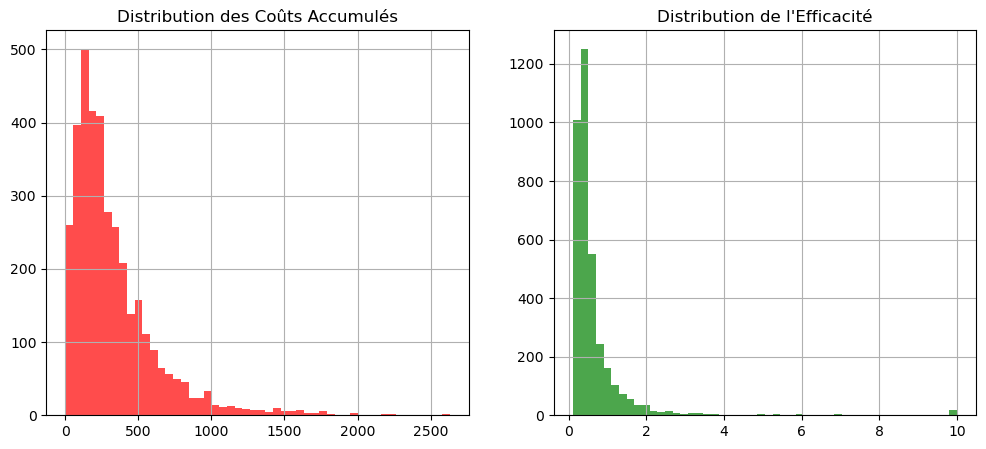

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gdf_lcp_clean['accumulated_cost'].hist(bins=50, ax=axes[0], color='red', alpha=0.7)
axes[0].set_title("Distribution des Coûts Accumulésoui)

gdf_lcp_clean['efficiency'].hist(bins=50, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title("Distribution de l'Efficacité")
plt.show()

/tmp/ipykernel_1392012/1450329685.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')


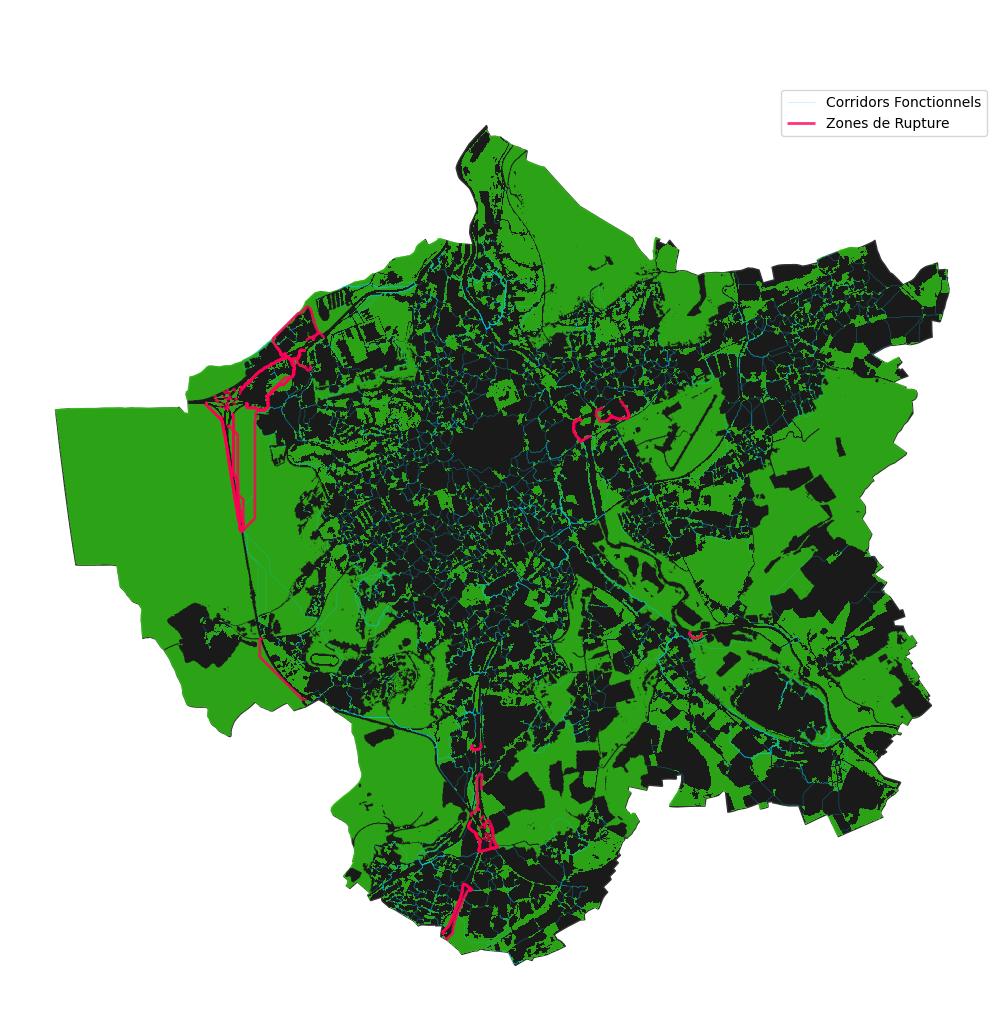

In [87]:
def plot_connectivity_ruptures(gdf_lcp, gdf_lcp_clean, aoi_utm, df_nodes):
    """
    Cartographie les zones de rupture (corridors supprimés) vs les corridors fonctionnels.
    """
    # 1. Identifier les corridors supprimés
    # On utilise un index commun (node_1, node_2) pour trouver la différence
    # On s'assure de travailler sur des index cohérents
    lcp_all = gdf_lcp.set_index(['node_1', 'node_2'])
    lcp_clean = gdf_lcp_clean.set_index(['node_1', 'node_2'])
    
    # Les corridors "rupture" sont ceux présents dans all mais pas dans clean
    rupture_corridors = lcp_all.drop(lcp_clean.index)
    
    # 2. Préparation de la carte
    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_facecolor('#0f0f0f') # Fond sombre
    
    # Fond
    aoi_utm.plot(ax=ax, color='#1a1a1a', edgecolor='#333333')
    
    # Corridors fonctionnels (en bleu discret)
    gdf_lcp_clean.plot(ax=ax, color='#00d4ff', alpha=0.3, linewidth=0.5, label='Corridors Fonctionnels')
    
    # Zones de rupture (en rouge vif et épais)
    if not rupture_corridors.empty:
        gpd.GeoDataFrame(rupture_corridors, crs=gdf_lcp.crs).plot(
            ax=ax, color='#ff0055', alpha=0.8, linewidth=2, label='Zones de Rupture'
        )
    
    # Nœuds (en vert)
    df_nodes.plot(ax=ax, color='#39ff14', markersize=5, alpha=0.6, label='Habitat Patches')
    
    plt.title(f"Diagnostic : Identification des barrières (Zones de rupture)\nNancy", 
              fontsize=16, color='white', pad=20)
    plt.legend(loc='upper right')
    ax.set_axis_off()
    plt.show()

# Exécuter la fonction
plot_connectivity_ruptures(gdf_lcp, gdf_lcp_clean, aoi_utm, df_nodes)

/tmp/ipykernel_1392012/2846115763.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')


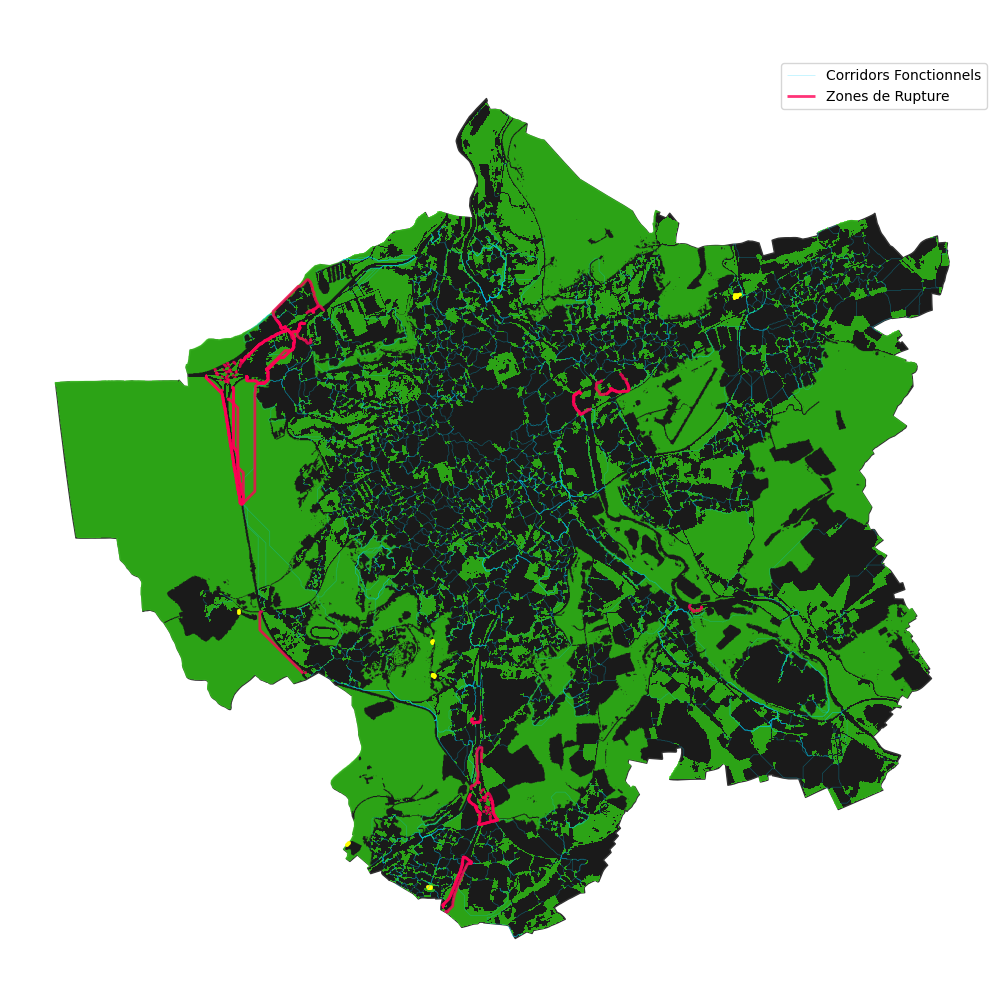

In [89]:
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_connectivity_diagnostic(gdf_lcp, gdf_lcp_clean, aoi_utm, df_nodes, G_lcp):
    """
    Cartographie les zones de rupture et encercle les habitats devenus isolés.
    """
    # 1. Identifier les corridors supprimés
    lcp_all = gdf_lcp.set_index(['node_1', 'node_2'])
    lcp_clean = gdf_lcp_clean.set_index(['node_1', 'node_2'])
    rupture_corridors = lcp_all.drop(lcp_clean.index, errors='ignore')
    
    # 2. Identifier les nœuds isolés (ceux qui n'ont plus d'arêtes connectées)
    isolated_nodes_list = list(nx.isolates(G_lcp))
    isolated_nodes_gdf = df_nodes[df_nodes.index.isin(isolated_nodes_list)]
    
    # 3. Préparation de la carte
    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_facecolor('#0f0f0f')
    
    aoi_utm.plot(ax=ax, color='#1a1a1a', edgecolor='#333333')
    
    # Corridors fonctionnels
    gdf_lcp_clean.plot(ax=ax, color='#00d4ff', alpha=0.3, linewidth=0.5, label='Corridors Fonctionnels')
    
    # Zones de rupture
    if not rupture_corridors.empty:
        gpd.GeoDataFrame(rupture_corridors, crs=gdf_lcp.crs).plot(
            ax=ax, color='#ff0055', alpha=0.8, linewidth=2, label='Zones de Rupture'
        )
    
    # Tous les habitats
    df_nodes.plot(ax=ax, color='#39ff14', markersize=5, alpha=0.6, label='Habitat Patches')
    
    # Bordure des habitats isolés (Effet "cible")
    if not isolated_nodes_gdf.empty:
        isolated_nodes_gdf.plot(ax=ax, facecolor='none', edgecolor='yellow', 
                                linewidth=2, markersize=150, label='Habitat Isolé (Isoloir)')

    plt.title("Diagnostic : Zones de rupture et habitats isolés", fontsize=16, color='white', pad=20)
    plt.legend(loc='upper right')
    ax.set_axis_off()
    plt.show()

# Exécuter avec le graphe nettoyé
plot_connectivity_diagnostic(gdf_lcp, gdf_lcp_clean, aoi_utm, df_nodes, G_lcp)

## 4.2. Corridors metrics: dPC, ebc

Identify critical links for network maintenance using two complementary metrics: 
- dPC (Flux): Ranks corridors by the volume of biodiversity flow they facilitate. Based on the overall PC index, measures the contribution of a single link to the total probability of connectivity across the landscape. Weighted by the surface area of the habitats connected, and dispersal probability between them. Prioritizes quantity (link between 2 massive reservoirs).
- Edge Betweenness Centrality (Rarity) : Highlights bottlenecks / bridge corridors vital for network cohesion. Measures how often a specific corridor is used as a "shortest path" to connect all possible pairs of habitats in the network. Their loss would fragment the system into isolated sub-units, they act as the only available path between distant parts of the network, regardless of the size of the patches they link. 

In [58]:
# dpc flux
gdf_lcp = conn.calculate_edge_dpc(gdf_lcp, G_lcp, total_area_km2, pc_real)

# edge betweenness centrality proxy dpc edge connector
gdf_lcp = conn.calculate_edge_betweenness(gdf_lcp, G_lcp)

### 4.2.1. Corridors categories

| Flow (dPC) | Rarity (EBC) | Corridor category |  
| :--- | :--- | :--- |   
| **High** | **High** | Ecological highway |  
| **Low** | **High** | Strategic bottleneck |  
| **High** | **Low** | Redundant mesh |  
| **Low** | **Low** | Local link |  

/home/jovyan/work/team/marion/corridor_project/modules/connectivity.py:572: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(title="Catégories de Corridors", loc='lower right', frameon=True, fontsize=10)


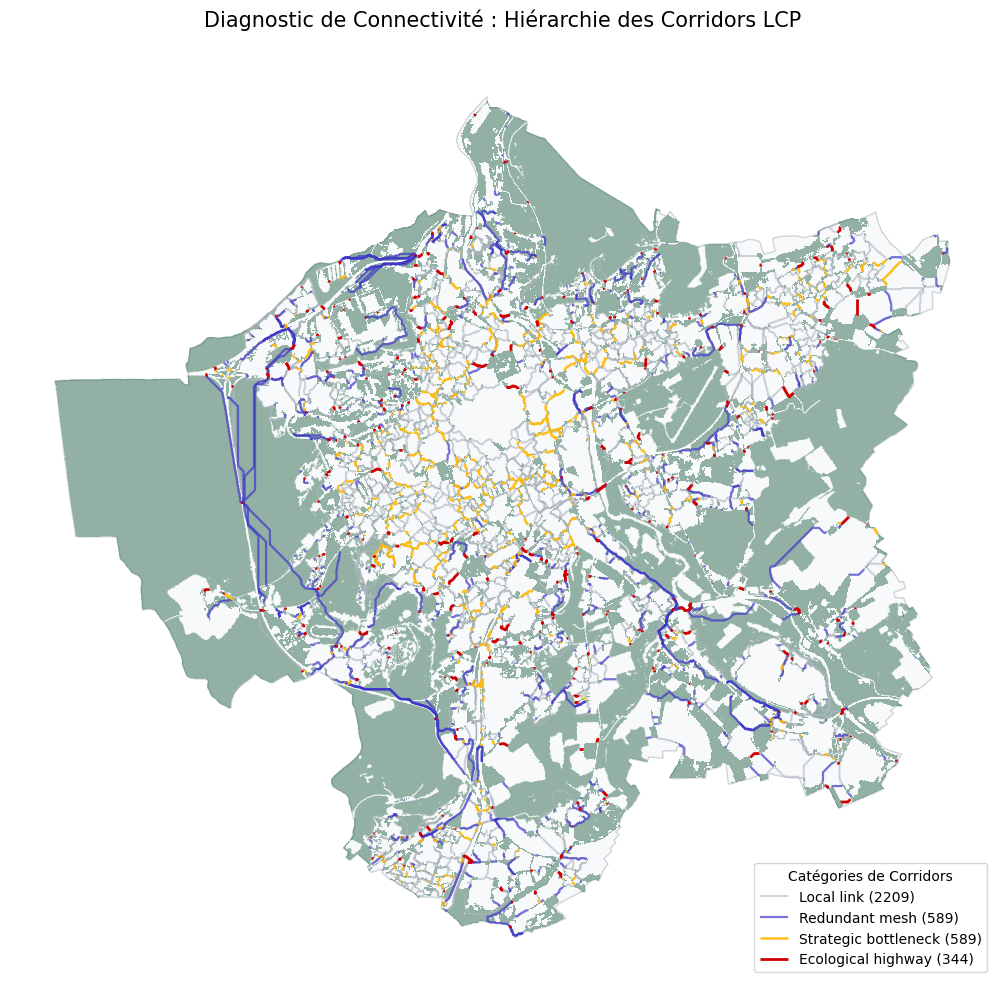

In [59]:
gdf_lcp = conn.classify_and_plot_corridors(gdf_lcp, df_nodes, aoi_utm, 0.75)
gdf_lcp.to_file(f"{OUTPUT_DIR}/lcp_{CITY}.json", driver='GeoJSON')

### 4.2.2. Heatmap, connectivity density

In [60]:
da_heatmap = conn.lcp_heatmap(gdf_lcp, aoi_utm, res=10, crs_utm=utm_epsg)
da_heatmap.rio.to_raster(f"{OUTPUT_DIR}/heatmap_lcp_{CITY}.tif")

/tmp/ipykernel_1392012/3260575621.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='white', labelcolor='white')


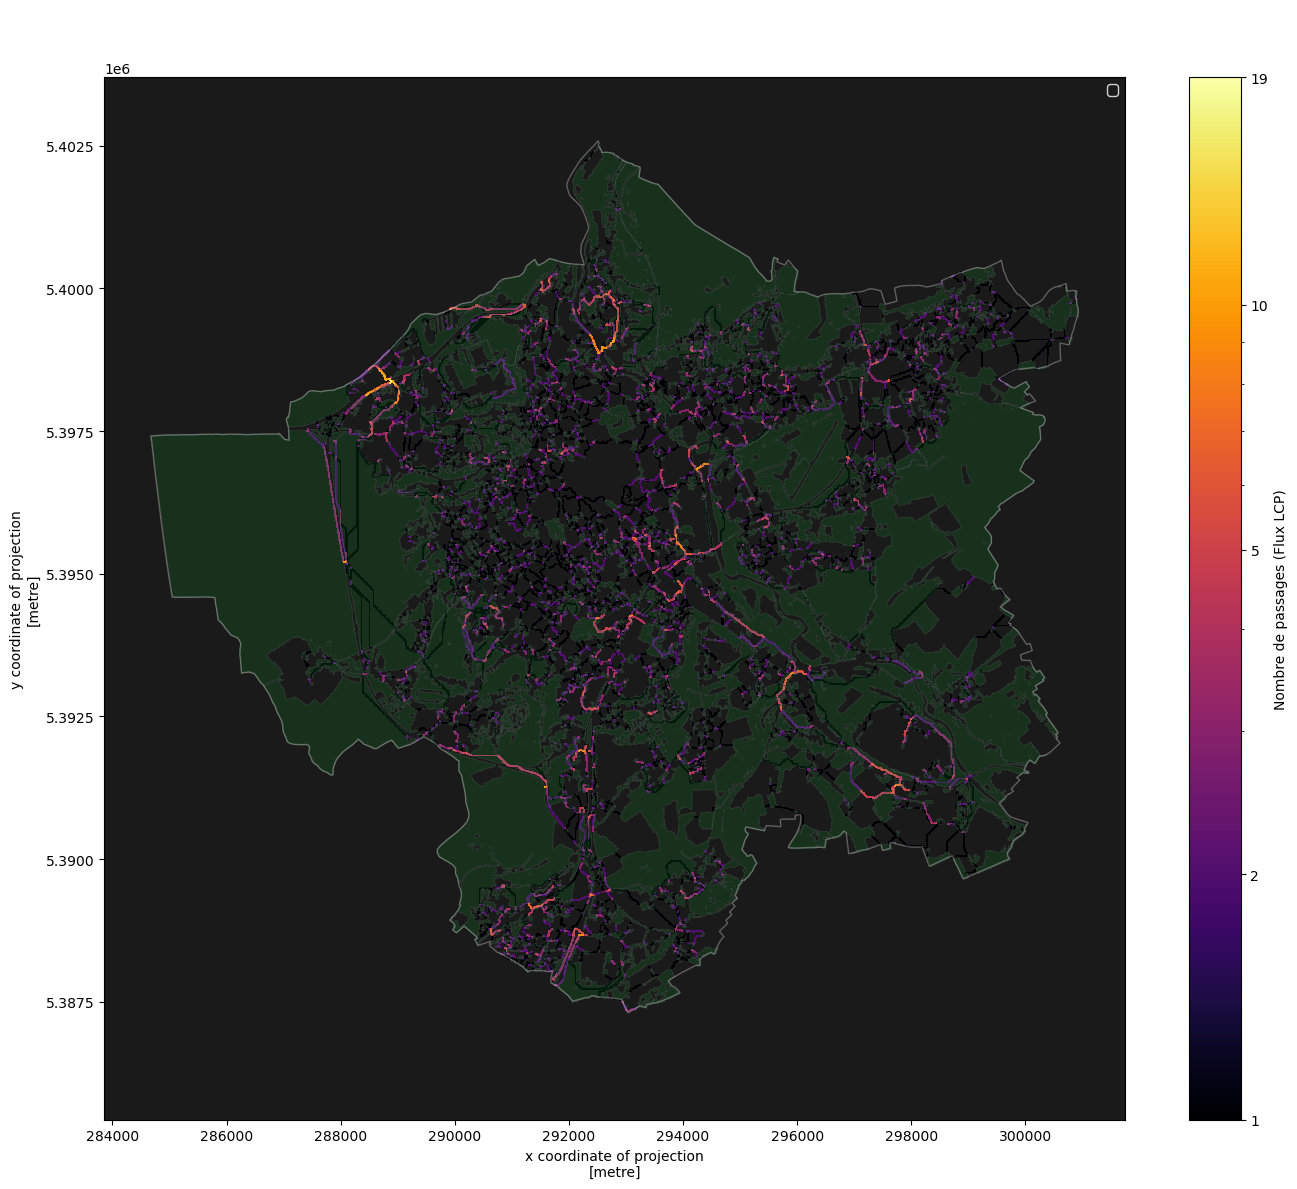

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import ScalarFormatter
from scipy import ndimage

# 1. Préparation de la heatmap
dilated_data = ndimage.maximum_filter(da_heatmap.values, size=3) 
da_heatmap_thick = da_heatmap.copy(data=dilated_data)
heatmap_plot = da_heatmap_thick.where(da_heatmap_thick > 0)

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#1a1a1a') # Fond sombre style "NASA"

# 2. Affichage de la Heatmap (Zorder 1)
vmax = int(da_heatmap_thick.max())
im = heatmap_plot.plot(
    ax=ax,
    cmap='inferno', 
    norm=colors.LogNorm(vmin=1, vmax=vmax),
    add_colorbar=True,
    zorder=1,
    cbar_kwargs={
        'label': 'Nombre de passages (Flux LCP)',
        'format': ScalarFormatter(), 
        'ticks': [1, 2, 5, 10, vmax]
    })

# 3. Affichage des Réservoirs et Islets (Zorder 2)
# --- AJOUT DES RÉSERVOIRS (Version corrigée) ---

# 1. On vérifie si df_nodes a un CRS. Sinon, on lui donne celui de l'AOI
if df_nodes.crs is None:
    print("Le CRS de df_nodes était manquant. Assignation du CRS de aoi_utm...")
    df_nodes.set_crs(aoi_utm.crs, inplace=True)

# 2. Maintenant on peut transformer sans erreur
nodes_to_plot = df_nodes.to_crs(da_heatmap.rio.crs)

# 3. On dessine
nodes_to_plot.plot(
    ax=ax, 
    color='#00ff41', # Vert néon
    alpha=0.1, 
    edgecolor='white',
    linewidth=0.5,
    markersize=20, # Ajuste selon la taille des points
    zorder=2
)

# 4. Habillage (Zorder 3)
aoi_utm.plot(ax=ax, facecolor="none", edgecolor="white", alpha=0.3, linewidth=1, zorder=3)

plt.title(f"Heatmap de Connectivité Fonctionnelle : {CITY}\nFlux LCP et localisation des réservoirs", 
          fontsize=15, pad=20, color='white')

# Optionnel : ajouter la légende pour les points
ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='white', labelcolor='white')

plt.axis('equal')
plt.tight_layout()
plt.show()

## 4.3. Nodes metrics: dPC

Analysis of the contribution of each patch to the global network. Connector fraction of the dPC index, which identifies patches that act as essential topological relays between other nodes, regardless of their own intrinsic area.
> warning : very long to compute, iterative node-removal simulations.

In [ ]:
df_nodes_connector = conn.calculate_node_dpc(G_lcp, total_area_km2, species_params=specie)
gdf_nodes = df_nodes.merge(df_nodes_connector, left_index=True, right_on='node_id')
gdf_nodes.set_crs(utm_epsg, inplace=True, allow_override=True)
gdf_nodes.to_file(f"{OUTPUT_DIR}/dpc_nodes_{CITY}.json", driver='GeoJSON')

Analyse de connectivité pour 1729 noyaux...


Calcul dPC Nodes:  40%|███▉      | 688/1729 [3:46:55<5:42:10, 19.72s/node]

______
# ***WIP***

# 5. Circuit Theory

Proxy flou gaussien au lieu de lois de Kirchoff résistance pour chaque pixel  
Définir les sources et les grounds  
Use a Cost-Distance Accumulation surface instead of just a Gaussian blur to show where paths converge.

## 5.1. Carte de conductance

In [295]:
# 1. Récupération de la friction spécifique à la guilde
friction_dict = specie['friction']

# 2. Création de la carte de friction (Reclassement)
# On initialise avec une valeur par défaut élevée pour les codes inconnus
da_friction = xr.where(da_lc.isnull(), 1000, 1000) 

for code, weight in friction_dict.items():
    da_friction = xr.where(da_lc == code, weight, da_friction)

# 3. Calcul de la Conductance brute (1 / Friction)
da_conductance = 1.0 / (da_friction + 0.1)

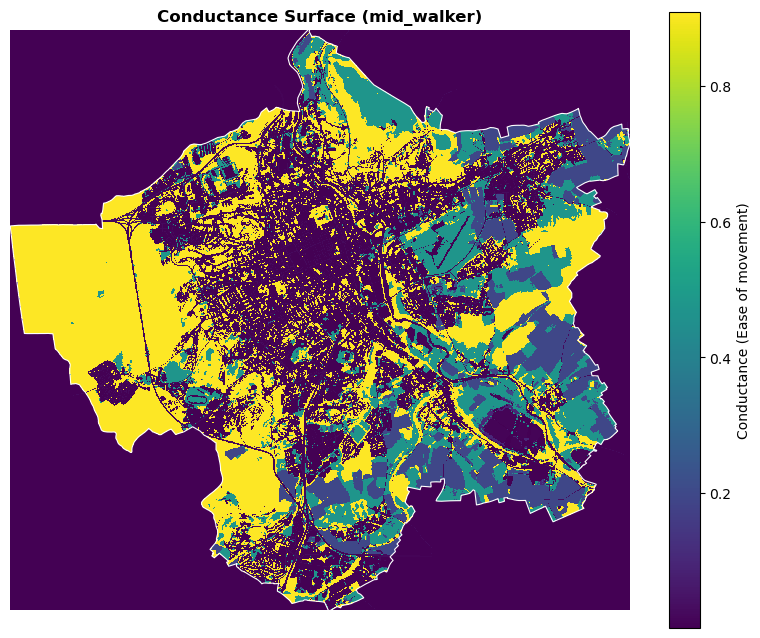

In [296]:
fig, ax = plt.subplots(figsize=(10, 8))

da_conductance.plot(
    ax=ax, 
    cmap='viridis', # jaune = passage facile, violet = barrière
    cbar_kwargs={'label': 'Conductance (Ease of movement)'}
)

aoi_utm.boundary.plot(ax=ax, color='white', linewidth=0.8)

ax.set_title(f"Conductance Surface ({GUILD_KEY})", fontweight='bold')
ax.set_axis_off()
plt.show()

## 5.2. Pinch points

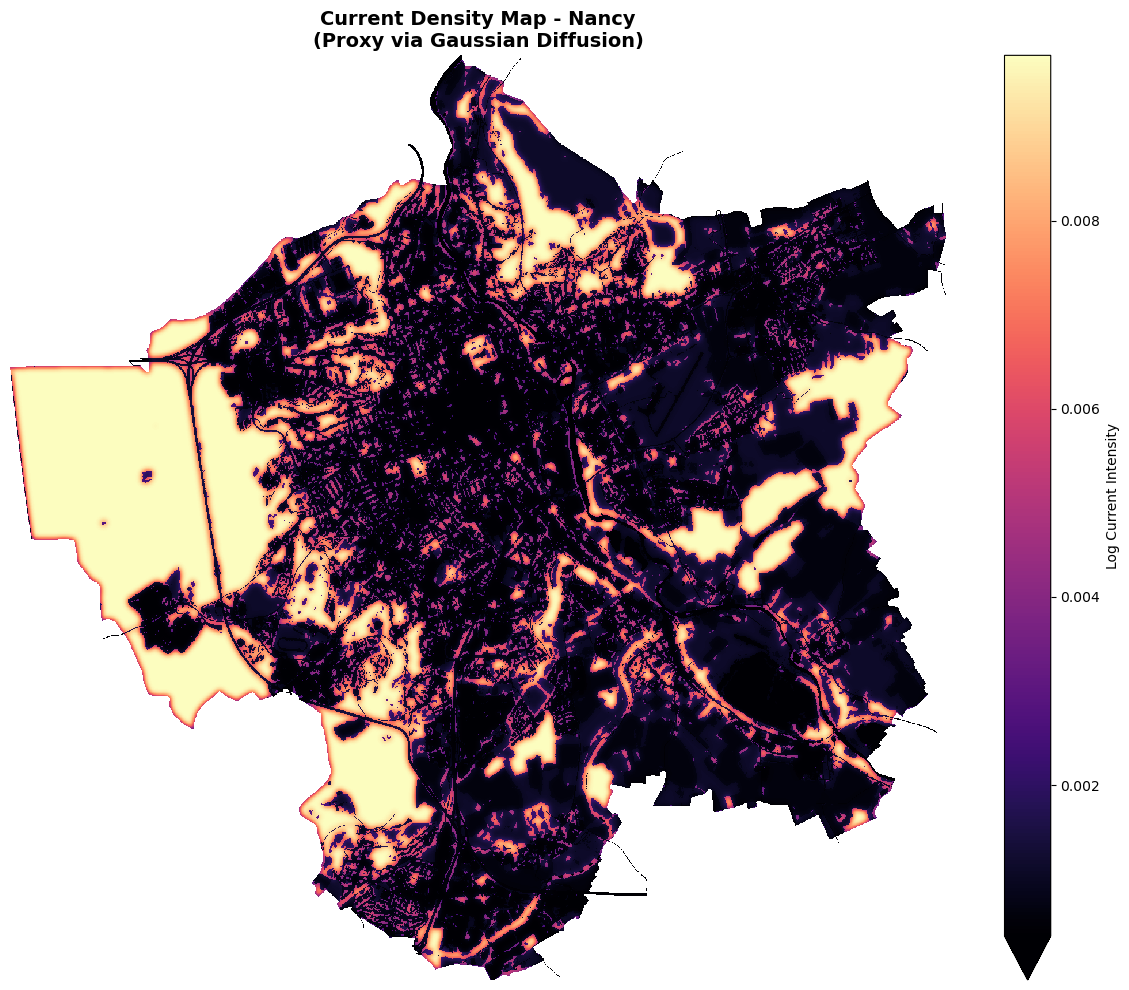

In [157]:
from scipy.ndimage import gaussian_filter

def calculate_pinch_points_proxy(da_friction, sigma=5):
    # Gestion des NaNs
    mask = da_friction.isnull()
    clean_friction = da_friction.fillna(da_friction.max())
    
    # 1. Conductance (Inverse de la friction)
    conductance = 1.0 / (clean_friction + 0.1)
    
    # 2. Diffusion proxy (Sigma plus élevé pour mieux voir les corridors)
    flow_spread = gaussian_filter(conductance.values, sigma=sigma)
    
    # Intensité de courant
    current_density = flow_spread * conductance.values
    
    da_current = da_friction.copy(data=current_density)
    return da_current.where(~mask)

# 1. Calcul
da_current_map = calculate_pinch_points_proxy(da_lc, sigma=5)

# 2. Visualisation simple
fig, ax = plt.subplots(figsize=(12, 10))

# On utilise log1p pour compresser la dynamique et voir les détails urbains
np.log1p(da_current_map).plot(
    ax=ax, 
    cmap='magma', 
    robust=True, 
    cbar_kwargs={'label': 'Log Current Intensity'}
)

ax.set_title(f"Current Density Map - {CITY}\n(Proxy via Gaussian Diffusion)", fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()